In [18]:
# ============================================================
#  PHASE 2 — USER SEGMENTATION (K-Means)
#  Input schema: impression_id, user_id, time, news_id,
#                clicked, category, subcategory, title
# ============================================================

# ---------- imports ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42

# ---------- load ----------
PATH = "/content/mind_merged_train.csv"   # adjust if needed
df = pd.read_csv(PATH)
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df["title"] = df["title"].fillna("")
df["category"] = df["category"].replace("foodanddrin", "foodanddrink")
print(f"Loaded {len(df):,} rows | {df['user_id'].nunique():,} users")

Loaded 5,843,444 rows | 50,000 users


In [19]:
# ===== STEP 1: BUILD USER-LEVEL FEATURE MATRIX =====

# --- activity level ---
activity = (df.groupby("user_id")["clicked"]
              .agg(impressions="size", clicks="sum"))
activity["ctr"] = activity["clicks"] / activity["impressions"]     # held out as OUTCOME
activity["log_impressions"] = np.log1p(activity["impressions"])
activity["log_clicks"] = np.log1p(activity["clicks"])

# --- category preference shares (one column per category) ---
cat_counts = (df.groupby(["user_id", "category"]).size()
                .unstack(fill_value=0))
cat_shares = cat_counts.div(cat_counts.sum(axis=1), axis=0)

# --- diversity: distinct categories + entropy of category mix ---
n_categories = cat_counts.gt(0).sum(axis=1).rename("n_categories")
P = cat_shares.values
with np.errstate(divide="ignore", invalid="ignore"):
    logP = np.where(P > 0, np.log(P), 0.0)
cat_entropy = pd.Series(-(P * logP).sum(axis=1),
                        index=cat_shares.index, name="entropy")

# --- temporal behaviour: time-of-day blocks + weekend share ---
df["hour"] = df["time"].dt.hour
df["block"] = pd.cut(df["hour"], bins=[-1, 5, 11, 17, 23],
                     labels=["night", "morning", "afternoon", "evening"])
block_counts = (df.groupby(["user_id", "block"], observed=False).size()
                  .unstack(fill_value=0))
block_shares = block_counts.div(block_counts.sum(axis=1), axis=0)
block_shares.columns = [f"time_{c}" for c in block_shares.columns]

df["is_weekend"] = df["time"].dt.dayofweek >= 5
weekend_share = df.groupby("user_id")["is_weekend"].mean().rename("weekend_share")

# --- assemble ---
cat_shares_named = cat_shares.add_prefix("cat_")
features = (activity
            .join(cat_shares_named)
            .join(n_categories)
            .join(cat_entropy)
            .join(block_shares)
            .join(weekend_share))
print("User feature matrix:", features.shape)
features.head()

User feature matrix: (50000, 28)


,impressions,clicks,ctr,log_impressions,log_clicks,cat_autos,cat_entertainment,cat_finance,cat_foodanddrink,cat_health,...,cat_tv,cat_video,cat_weather,n_categories,entropy,time_night,time_morning,time_afternoon,time_evening,weekend_share
user_id,,,,,,,,,,,,,,,,,,,,,
U100,105,1,0.009524,4.663439,0.693147,0.000000,0.104762,0.104762,0.019048,0.000000,...,0.019048,0.000000,0.028571,10,1.888718,0.00000,1.000000,0.000000,0.00000,0.0
U1000,205,4,0.019512,5.327876,1.609438,0.048780,0.073171,0.117073,0.058537,0.048780,...,0.024390,0.014634,0.024390,14,2.322612,0.44878,0.000000,0.000000,0.55122,0.0
U10001,84,3,0.035714,4.442651,1.386294,0.071429,0.023810,0.083333,0.071429,0.047619,...,0.011905,0.011905,0.011905,13,2.183180,1.00000,0.000000,0.000000,0.00000,0.0
U10003,106,3,0.028302,4.672829,1.386294,0.047170,0.047170,0.066038,0.047170,0.103774,...,0.047170,0.047170,0.000000,13,2.251014,0.00000,0.066038,0.933962,0.00000,0.0
U10008,72,1,0.013889,4.290459,0.693147,0.000000,0.069444,0.000000,0.000000,0.097222,...,0.111111,0.000000,0.083333,10,1.868120,0.00000,0.000000,1.000000,0.00000,1.0


In [20]:
# ===== STEP 2: FILTER LOW-ACTIVITY USERS =====
MIN_IMPRESSIONS = 10
before = len(features)
features = features[features["impressions"] >= MIN_IMPRESSIONS].copy()
print(f"Dropped {before - len(features):,} users with < {MIN_IMPRESSIONS} "
      f"impressions ({(before-len(features))/before:.1%}). "
      f"Remaining: {len(features):,}")

Dropped 5,665 users with < 10 impressions (11.3%). Remaining: 44,335


In [21]:
# ===== STEP 3: SELECT CLUSTERING FEATURES & SCALE =====
# Cluster on behaviour/preference. CTR, raw counts kept aside as outcomes.
cluster_cols = (
    [c for c in features.columns if c.startswith("cat_")] +      # category mix
    [c for c in features.columns if c.startswith("time_")] +     # timing
    ["weekend_share", "n_categories", "entropy",             # diversity
     "log_impressions", "log_clicks"]                            # activity level
)
X = features[cluster_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X)
print(f"Clustering on {len(cluster_cols)} features:\n{cluster_cols}")

Clustering on 25 features:
['cat_autos', 'cat_entertainment', 'cat_finance', 'cat_foodanddrink', 'cat_health', 'cat_kids', 'cat_lifestyle', 'cat_movies', 'cat_music', 'cat_news', 'cat_northamerica', 'cat_sports', 'cat_travel', 'cat_tv', 'cat_video', 'cat_weather', 'time_night', 'time_morning', 'time_afternoon', 'time_evening', 'weekend_share', 'n_categories', 'entropy', 'log_impressions', 'log_clicks']


k=2: inertia=994,781  silhouette=0.1829
k=3: inertia=946,570  silhouette=0.0871
k=4: inertia=904,416  silhouette=0.0772
k=5: inertia=867,639  silhouette=0.0866
k=6: inertia=833,369  silhouette=0.0911
k=7: inertia=796,957  silhouette=0.0913
k=8: inertia=774,872  silhouette=0.0950
k=9: inertia=744,200  silhouette=0.0886
k=10: inertia=724,493  silhouette=0.0969


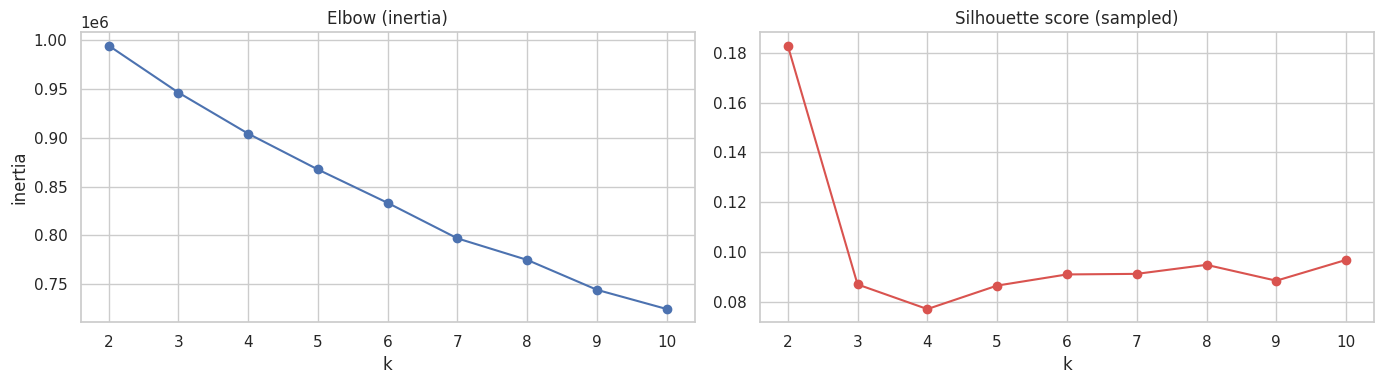

In [22]:
# ===== STEP 4: CHOOSE k  (Elbow + Silhouette) =====
# Silhouette on full data is O(n^2); compute it on a sample for speed.
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_scaled), size=min(8000, len(X_scaled)), replace=False)

ks = range(2, 11)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))
    print(f"k={k}: inertia={km.inertia_:,.0f}  silhouette={sil[-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(ks), inertia, marker="o"); ax[0].set_title("Elbow (inertia)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia")
ax[1].plot(list(ks), sil, marker="o", color="#d9534f")
ax[1].set_title("Silhouette score (sampled)"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()

In [23]:
# ===== STEP 5: FIT FINAL MODEL =====
K = 4   # <-- set from the elbow/silhouette plots above
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
features["segment"] = kmeans.fit_predict(X_scaled)

print("Segment sizes:")
print(features["segment"].value_counts().sort_index()
      .to_frame("users").assign(share=lambda d: d["users"]/len(features)))

Segment sizes:
         users     share
segment                 
0         6805  0.153490
1        16332  0.368377
2         9699  0.218766
3        11499  0.259366


=== SEGMENT PROFILES ===


,users,avg_impressions,avg_clicks,avg_ctr,n_categories,cat_entropy,weekend_share
segment,,,,,,,
0,6805,50.899,2.975,0.094,8.237,1.576,0.319
1,16332,241.801,8.983,0.041,13.429,2.219,0.219
2,9699,75.300,3.034,0.055,11.879,2.176,0.162
3,11499,68.749,2.865,0.056,11.556,2.144,0.079



=== TOP CATEGORIES PER SEGMENT ===
Segment 0: news (46%), sports (13%), finance (10%)
Segment 1: news (26%), lifestyle (11%), sports (10%)
Segment 2: news (24%), lifestyle (12%), sports (11%)
Segment 3: news (25%), lifestyle (13%), finance (12%)

=== TIME-OF-DAY MIX PER SEGMENT ===


,time_night,time_morning,time_afternoon,time_evening
segment,,,,
0,0.270,0.344,0.217,0.169
1,0.231,0.357,0.232,0.180
2,0.018,0.081,0.845,0.056
3,0.024,0.917,0.047,0.012


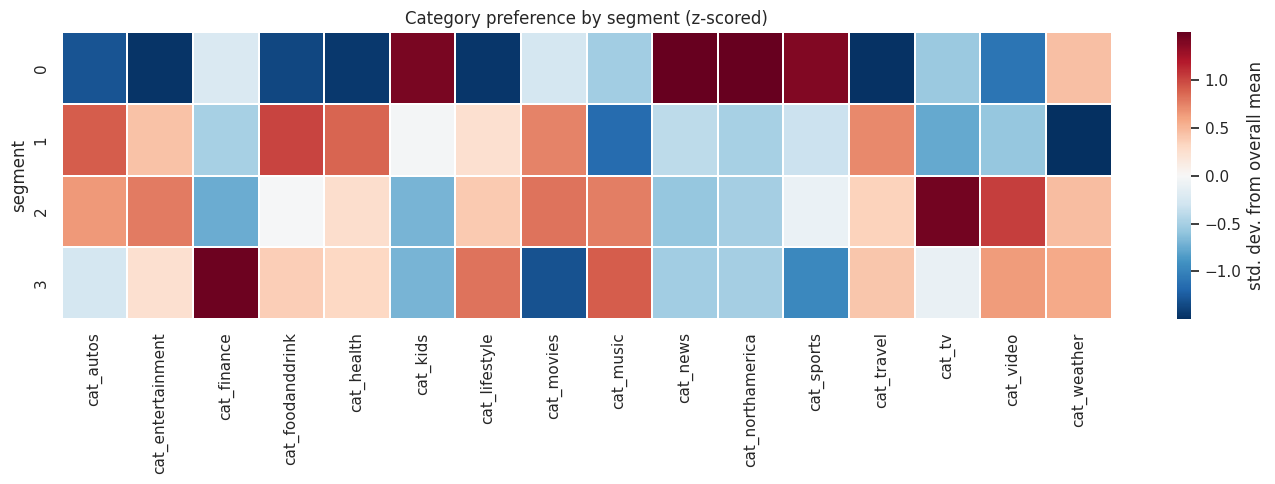

In [24]:
# ===== STEP 6: PROFILE SEGMENTS INTO PERSONAS =====
profile = features.groupby("segment").agg(
    users=("ctr", "size"),
    avg_impressions=("impressions", "mean"),
    avg_clicks=("clicks", "mean"),
    avg_ctr=("ctr", "mean"),                 # OUTCOME compared across segments
    n_categories=("n_categories", "mean"),
    cat_entropy=("entropy", "mean"),
    weekend_share=("weekend_share", "mean"),
)

# dominant category lean per segment (top 3 categories by mean share)
cat_profile = features.groupby("segment")[
    [c for c in features.columns if c.startswith("cat_")]].mean()
print("=== SEGMENT PROFILES ===")
display(profile.round(3))

print("\n=== TOP CATEGORIES PER SEGMENT ===")
for seg in sorted(features["segment"].unique()):
    top = cat_profile.loc[seg].sort_values(ascending=False).head(3)
    tops = ", ".join(f"{c.replace('cat_','')} ({v:.0%})" for c, v in top.items())
    print(f"Segment {seg}: {tops}")

# time-of-day lean per segment
time_profile = features.groupby("segment")[
    [c for c in features.columns if c.startswith("time_")]].mean()
print("\n=== TIME-OF-DAY MIX PER SEGMENT ===")
display(time_profile.round(3))

# heatmap of category lean by segment (z-scored for readability)
z = (cat_profile - cat_profile.mean()) / cat_profile.std()
plt.figure(figsize=(14, 5))
sns.heatmap(z, cmap="RdBu_r", center=0, linewidths=.3,
            cbar_kws={"label": "std. dev. from overall mean"})
plt.title("Category preference by segment (z-scored)")
plt.ylabel("segment"); plt.tight_layout(); plt.show()

In [25]:
# ===== STEP 7: ATTACH LABELS BACK & (OPTIONAL) SAVE =====
df = df.merge(features["segment"], left_on="user_id", right_index=True, how="left")
# users below the activity threshold get segment = NaN
print("Impression rows with a segment label:",
      f"{df['segment'].notna().sum():,} / {len(df):,}")

# per-segment CTR on the full impression data (validates the persona story)
seg_ctr = df.dropna(subset=["segment"]).groupby("segment")["clicked"].mean()
print("\nCTR by segment (impression-level):")
print(seg_ctr.round(4))

# save the user-level feature+segment table for your write-up
features.to_csv("/content/user_segments.csv")
print("\nSaved user_segments.csv")

Impression rows with a segment label: 5,816,341 / 5,843,444

CTR by segment (impression-level):
segment
0.0    0.0584
1.0    0.0371
2.0    0.0403
3.0    0.0417
Name: clicked, dtype: float64

Saved user_segments.csv


In [26]:
# ===== STEP 8: CONTENT-DRIVEN SEGMENTATION (comparison run) =====
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# keep the existing (time-driven) labels under a clear name
features["segment_time"] = features["segment"]

# content-driven feature set: NO time_* and NO weekend_share
content_cols = (
    [c for c in features.columns if c.startswith("cat_")] +   # category preference
    ["n_categories", "entropy"]                               # diversity
)
Xc = features[content_cols].fillna(0)
Xc_scaled = StandardScaler().fit_transform(Xc)

# outlier guard: clip extreme z-scores so a lone user can't claim its own cluster
Xc_scaled = np.clip(Xc_scaled, -5, 5)
print(f"Content clustering on {len(content_cols)} taste features (clipped):")
print(content_cols)

Content clustering on 18 taste features (clipped):
['cat_autos', 'cat_entertainment', 'cat_finance', 'cat_foodanddrink', 'cat_health', 'cat_kids', 'cat_lifestyle', 'cat_movies', 'cat_music', 'cat_news', 'cat_northamerica', 'cat_sports', 'cat_travel', 'cat_tv', 'cat_video', 'cat_weather', 'n_categories', 'entropy']


k=2: inertia=600,169  silhouette=0.2353
k=3: inertia=562,245  silhouette=0.1182
k=4: inertia=536,173  silhouette=0.1173
k=5: inertia=514,855  silhouette=0.0807
k=6: inertia=496,598  silhouette=0.0764
k=7: inertia=479,318  silhouette=0.0778
k=8: inertia=465,018  silhouette=0.0782
k=9: inertia=452,208  silhouette=0.0772
k=10: inertia=440,175  silhouette=0.0781


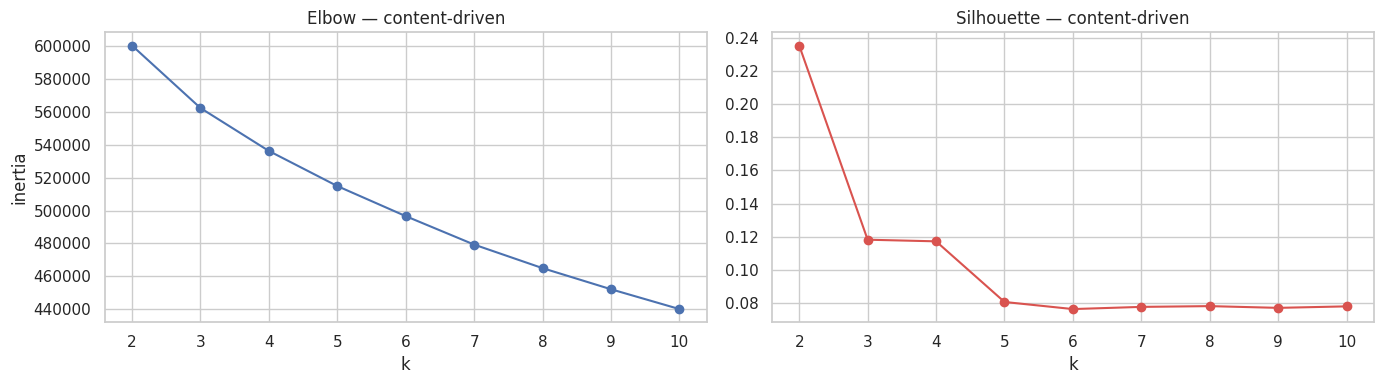

In [27]:
# ===== STEP 9: CHOOSE k FOR CONTENT-DRIVEN =====
sample_idx_c = np.random.RandomState(RANDOM_STATE).choice(
    len(Xc_scaled), size=min(8000, len(Xc_scaled)), replace=False)

ks = range(2, 11)
inertia_c, sil_c = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lab = km.fit_predict(Xc_scaled)
    inertia_c.append(km.inertia_)
    sil_c.append(silhouette_score(Xc_scaled[sample_idx_c], lab[sample_idx_c]))
    print(f"k={k}: inertia={km.inertia_:,.0f}  silhouette={sil_c[-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(ks), inertia_c, marker="o"); ax[0].set_title("Elbow — content-driven")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia")
ax[1].plot(list(ks), sil_c, marker="o", color="#d9534f")
ax[1].set_title("Silhouette — content-driven"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()

In [28]:
# ===== STEP 10: FIT CONTENT-DRIVEN MODEL =====
# default to the same k as the time-driven run for a like-for-like comparison;
# change if the plots above clearly favour a different k.
CONTENT_K = 3
km_c = KMeans(n_clusters=CONTENT_K, random_state=RANDOM_STATE, n_init=10)
features["segment_content"] = km_c.fit_predict(Xc_scaled)

print("Content-segment sizes:")
print(features["segment_content"].value_counts().sort_index()
      .to_frame("users").assign(share=lambda d: d["users"]/len(features)))
sizes = features["segment_content"].value_counts()
assert sizes.min() >= 30, "Degenerate cluster detected — lower k or check outliers"


Content-segment sizes:
                 users     share
segment_content                 
0                 5344  0.120537
1                24096  0.543498
2                14895  0.335965


In [29]:
# ===== STEP 11: PROFILE CONTENT SEGMENTS =====
prof_c = features.groupby("segment_content").agg(
    users=("ctr", "size"),
    avg_impressions=("impressions", "mean"),
    avg_clicks=("clicks", "mean"),
    avg_ctr=("ctr", "mean"),                 # OUTCOME
    n_categories=("n_categories", "mean"),
    entropy=("entropy", "mean"),
)
print("=== CONTENT SEGMENT PROFILES ===")
display(prof_c.round(3))

# what defines them: category lean
catprof_c = features.groupby("segment_content")[
    [c for c in features.columns if c.startswith("cat_")]].mean()
print("\n=== TOP CATEGORIES PER CONTENT SEGMENT ===")
for seg in sorted(features["segment_content"].unique()):
    top = catprof_c.loc[seg].sort_values(ascending=False).head(3)
    print(f"Segment {seg}: " +
          ", ".join(f"{c.replace('cat_','')} ({v:.0%})" for c, v in top.items()))

# time brought back PURELY as a profiling variable (did not drive clustering)
print("\n=== TIME-OF-DAY MIX PER CONTENT SEGMENT (profiling only) ===")
timeprof_c = features.groupby("segment_content")[
    [c for c in features.columns if c.startswith("time_")]].mean()
display(timeprof_c.round(3))
print("Weekend share per content segment:")
display(features.groupby("segment_content")["weekend_share"].mean().round(3))

=== CONTENT SEGMENT PROFILES ===


,users,avg_impressions,avg_clicks,avg_ctr,n_categories,entropy
segment_content,,,,,,
0,5344,61.655,3.359,0.095,7.863,1.476
1,24096,175.166,6.115,0.040,12.964,2.231
2,14895,84.998,4.297,0.069,11.352,2.087



=== TOP CATEGORIES PER CONTENT SEGMENT ===
Segment 0: news (50%), sports (12%), finance (10%)
Segment 1: news (25%), lifestyle (12%), finance (10%)
Segment 2: news (27%), sports (12%), lifestyle (12%)

=== TIME-OF-DAY MIX PER CONTENT SEGMENT (profiling only) ===


,time_night,time_morning,time_afternoon,time_evening
segment_content,,,,
0,0.225,0.389,0.258,0.128
1,0.137,0.447,0.316,0.100
2,0.105,0.445,0.338,0.112


Weekend share per content segment:


,weekend_share
segment_content,
0,0.312
1,0.176
2,0.155


Adjusted Rand Index:        0.207
Normalized Mutual Info:     0.266
(0 = the two segmentations are unrelated; 1 = identical groupings)


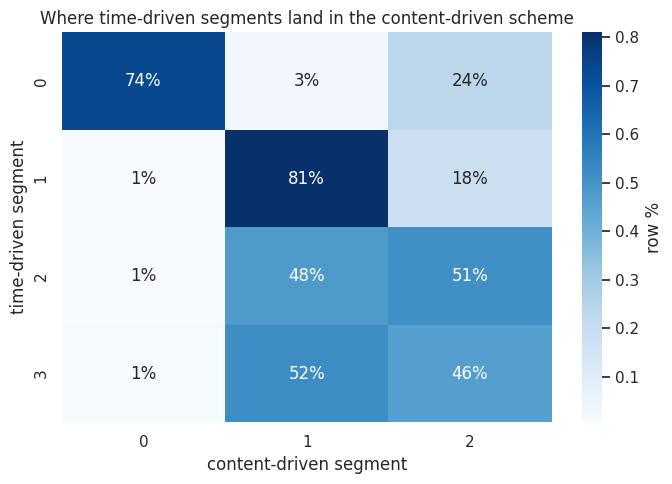

In [30]:
# ===== STEP 12: COMPARE TIME-DRIVEN vs CONTENT-DRIVEN =====
ari = adjusted_rand_score(features["segment_time"], features["segment_content"])
nmi = normalized_mutual_info_score(features["segment_time"], features["segment_content"])
print(f"Adjusted Rand Index:        {ari:.3f}")
print(f"Normalized Mutual Info:     {nmi:.3f}")
print("(0 = the two segmentations are unrelated; 1 = identical groupings)")

# contingency: how users flow between the two schemes
ct = pd.crosstab(features["segment_time"], features["segment_content"],
                 normalize="index")
plt.figure(figsize=(7, 5))
sns.heatmap(ct, annot=True, fmt=".0%", cmap="Blues",
            cbar_kws={"label": "row %"})
plt.title("Where time-driven segments land in the content-driven scheme")
plt.xlabel("content-driven segment"); plt.ylabel("time-driven segment")
plt.tight_layout(); plt.show()